# Image Classifier: Dogs vs Cats
This project builds a Convolutional Neural Network (CNN) to classify images of dogs and cats using the Kaggle Asirra dataset. We load the data, visualize samples, build a VGG16-inspired model, optimize it with callbacks, and save the best result.

## Step 0: Prepare the folder structure
The Kaggle zip extracts flat files named `cat.0.jpg` / `dog.0.jpg`. We sort them into `data/raw/cat/` and `data/raw/dog/` subfolders, and also create a `data/processed/` split with separate `train/` and `test/` directories for Keras.

In [8]:
import os, shutil, glob, subprocess

ZIP_PATH = 'data/raw/dogs-vs-cats.zip'
RAW_DIR  = 'data/raw'

# Extract zip if not already done (uses 7z to handle truncated archives)
train_extracted = os.path.join(RAW_DIR, 'dogs-vs-cats', 'train')
if not os.path.exists(os.path.join(RAW_DIR, 'cat')) and not os.path.exists(train_extracted):
    print('Extracting zip with 7z...')
    subprocess.run(['7z', 'x', ZIP_PATH, f'-o{RAW_DIR}', '-y'], capture_output=True)
    print('Extraction done.')

# Find the flat train folder
candidates = [
    RAW_DIR,
    os.path.join(RAW_DIR, 'train'),
    os.path.join(RAW_DIR, 'dogs-vs-cats', 'train'),
]
FLAT_DIR = next((p for p in candidates if glob.glob(os.path.join(p, 'cat.*.jpg'))), None)
print('Flat images found in:', FLAT_DIR)

# Create dog/ and cat/ subfolders inside raw/
for cls in ['cat', 'dog']:
    os.makedirs(os.path.join(RAW_DIR, cls), exist_ok=True)

if FLAT_DIR:
    for cls in ['cat', 'dog']:
        files = glob.glob(os.path.join(FLAT_DIR, f'{cls}.*.jpg'))
        for f in files:
            dest = os.path.join(RAW_DIR, cls, os.path.basename(f))
            if not os.path.exists(dest):
                shutil.copy(f, dest)

print('Cats in raw/cat:', len(os.listdir(os.path.join(RAW_DIR, 'cat'))))
print('Dogs in raw/dog:', len(os.listdir(os.path.join(RAW_DIR, 'dog'))))

Flat images found in: data/raw/dogs-vs-cats/train
Cats in raw/cat: 10830
Dogs in raw/dog: 10844


In [9]:
# Create train/test split for flow_from_directory
BASE_DIR  = 'data/processed/dogs-vs-cats'
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
TEST_DIR  = os.path.join(BASE_DIR, 'test')
TRAIN_N, TEST_N = 500, 100

for split in ['train', 'test']:
    for cls in ['cat', 'dog']:
        os.makedirs(os.path.join(BASE_DIR, split, cls), exist_ok=True)

for cls in ['cat', 'dog']:
    files = sorted(glob.glob(os.path.join(RAW_DIR, cls, '*.jpg')))
    for f in files[:TRAIN_N]:
        dest = os.path.join(TRAIN_DIR, cls, os.path.basename(f))
        if not os.path.exists(dest): shutil.copy(f, dest)
    for f in files[TRAIN_N:TRAIN_N+TEST_N]:
        dest = os.path.join(TEST_DIR, cls, os.path.basename(f))
        if not os.path.exists(dest): shutil.copy(f, dest)

print('Train cats:', len(os.listdir(os.path.join(TRAIN_DIR, 'cat'))))
print('Train dogs:', len(os.listdir(os.path.join(TRAIN_DIR, 'dog'))))
print('Test  cats:', len(os.listdir(os.path.join(TEST_DIR,  'cat'))))
print('Test  dogs:', len(os.listdir(os.path.join(TEST_DIR,  'dog'))))

Train cats: 500
Train dogs: 500
Test  cats: 100
Test  dogs: 100


## Step 1: Load the Dataset
We use Keras `ImageDataGenerator` with `flow_from_directory()` to load images progressively, which works on limited RAM. Images are resized to 224x224 pixels and normalized to [0,1]. 20% of training images are kept for validation.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (64, 64)
BATCH    = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.2
)
test_datagen = ImageDataGenerator(rescale=1./255)

trdata = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH,
    class_mode='categorical', subset='training'
)
valdata = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH,
    class_mode='categorical', subset='validation'
)
tsdata = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH,
    class_mode='categorical', shuffle=False
)

print('Classes:', trdata.class_indices)

Found 800 images belonging to 2 classes.
Found 200 images belonging to 2 classes.
Found 200 images belonging to 2 classes.
Classes: {'cat': 0, 'dog': 1}


## Step 2: Visualize the Input Data
We display the first 9 dogs and 9 cats from `data/raw/dog/` and `data/raw/cat/` to understand the variety of shapes, sizes, and angles the model must handle.

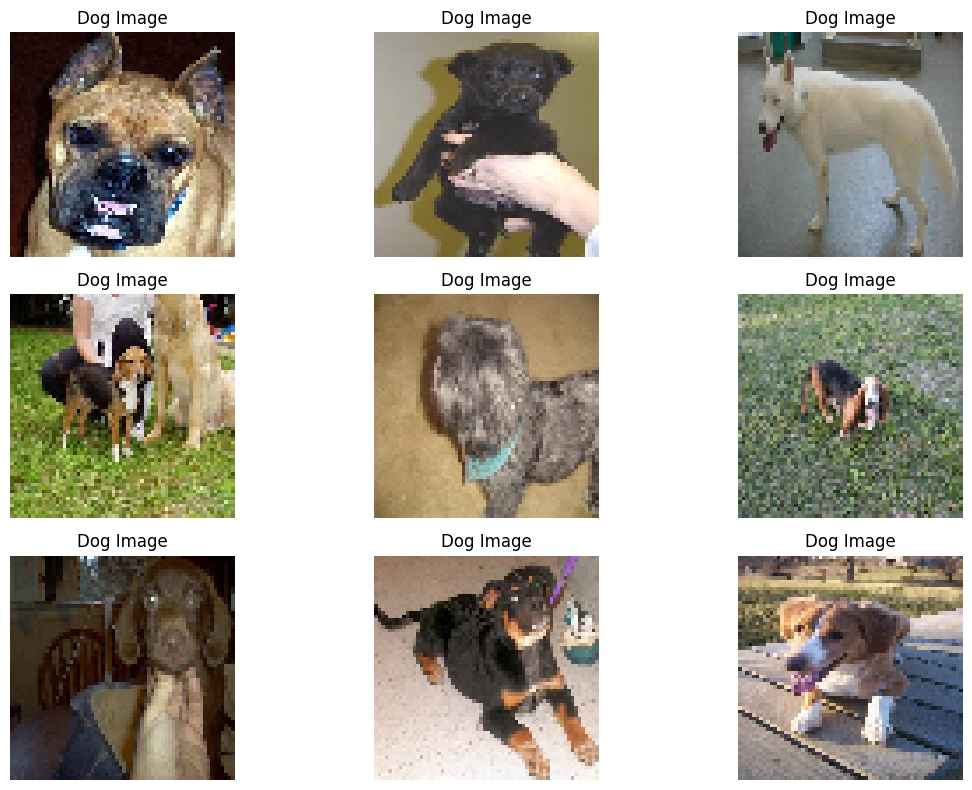

In [11]:
# Show first 9 dog images
data_dir = 'data/raw'
dog_subfolder = os.path.join(data_dir, 'dog')
dog_image_files = os.listdir(dog_subfolder)

dog_images = []
for i in range(9):
    img_path = os.path.join(dog_subfolder, dog_image_files[i])
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array /= 255.0
    dog_images.append(img_array)

plt.figure(figsize=(12, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(dog_images[i])
    plt.title('Dog Image')
    plt.axis('off')
plt.tight_layout()
plt.show()

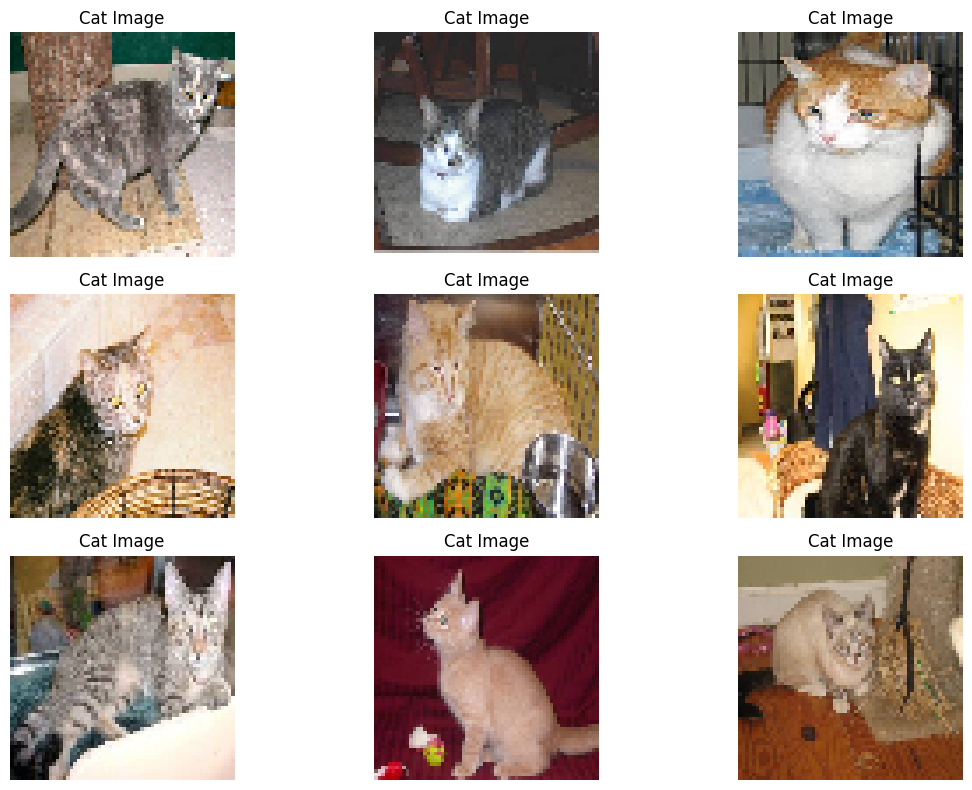

In [12]:
# Show first 9 cat images
cat_subfolder = os.path.join(data_dir, 'cat')
cat_image_files = os.listdir(cat_subfolder)

cat_images = []
for i in range(9):
    img_path = os.path.join(cat_subfolder, cat_image_files[i])
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array /= 255.0
    cat_images.append(img_array)

plt.figure(figsize=(12, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(cat_images[i])
    plt.title('Cat Image')
    plt.axis('off')
plt.tight_layout()
plt.show()

## Step 3: Build the CNN (VGG16-inspired)
We use the VGG16 architecture that won the Kaggle ILSVR (ImageNet) competition in 2014. It stacks Conv2D and MaxPool2D layers to extract spatial features, followed by Dense layers for classification. The output layer has 2 units with softmax for binary cat/dog classification.

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPool2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Input(shape=(64, 64, 3)),
    Conv2D(filters=64,  kernel_size=(3,3), padding='same', activation='relu'),
    Conv2D(filters=64,  kernel_size=(3,3), padding='same', activation='relu'),
    MaxPool2D(pool_size=(2,2), strides=(2,2)),

    Conv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu'),
    Conv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPool2D(pool_size=(2,2), strides=(2,2)),

    Conv2D(filters=256, kernel_size=(3,3), padding='same', activation='relu'),
    Conv2D(filters=256, kernel_size=(3,3), padding='same', activation='relu'),
    Conv2D(filters=256, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPool2D(pool_size=(2,2), strides=(2,2)),

    Conv2D(filters=512, kernel_size=(3,3), padding='same', activation='relu'),
    Conv2D(filters=512, kernel_size=(3,3), padding='same', activation='relu'),
    Conv2D(filters=512, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPool2D(pool_size=(2,2), strides=(2,2)),

    Conv2D(filters=512, kernel_size=(3,3), padding='same', activation='relu'),
    Conv2D(filters=512, kernel_size=(3,3), padding='same', activation='relu'),
    Conv2D(filters=512, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPool2D(pool_size=(2,2), strides=(2,2)),

    Flatten(),
    Dense(units=4096, activation='relu'),
    Dropout(0.5),
    Dense(units=4096, activation='relu'),
    Dropout(0.5),
    Dense(units=2, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4096)           │     8,392,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │         8,194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,896,898 (152.19 MB)

 Trainable params: 39,896,898 (152.19 MB)

 Non-trainable params: 0 (0.00 B)

## Step 4: Optimize the Model
We attach `EarlyStopping` to stop training when validation loss stops improving, and `ModelCheckpoint` to save the best weights automatically. These two callbacks together prevent overfitting and ensure we keep the best model found across all epochs.

In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

os.makedirs('models', exist_ok=True)

checkpoint = ModelCheckpoint(
    filepath='models/best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    trdata,
    epochs=30,
    validation_data=valdata,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4794 - loss: 0.6937
Epoch 1: val_accuracy improved from None to 0.50000, saving model to models/best_model.keras

Epoch 1: finished saving model to models/best_model.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.4950 - loss: 0.6936 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4618 - loss: 0.6935
Epoch 2: val_accuracy did not improve from 0.50000
25/25 ━━━━━━━━━━━━━━━━━━━━ 71s 3s/step - accuracy: 0.4563 - loss: 0.6934 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4629 - loss: 0.6933
Epoch 3: val_accuracy did not improve from 0.50000
25/25 ━━━━━━━━━━━━━━━━━━━━ 69s 3s/step - accuracy: 0.4762 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4860 - loss: 0.6932
Epoch 4: val_accuracy did not improve from 0.50000
25/25 ━━━━━━━━━━━━

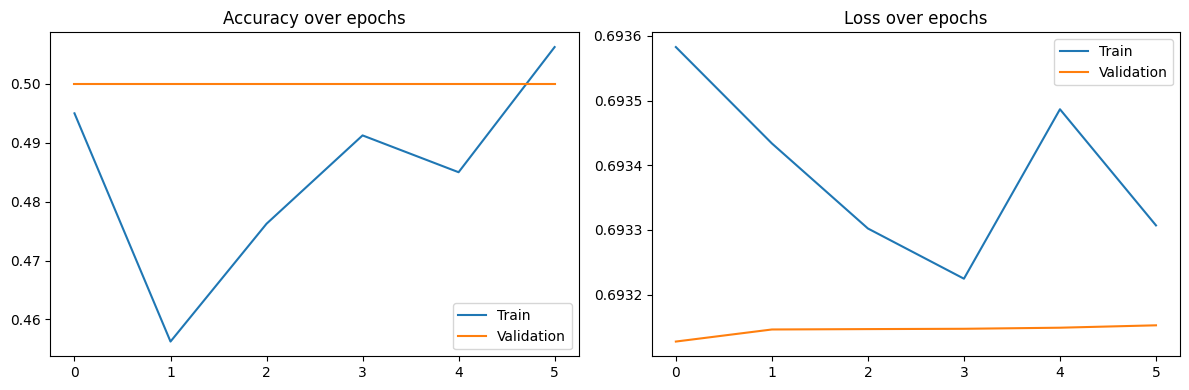

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy over epochs'); axes[0].legend()
axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss over epochs'); axes[1].legend()
plt.tight_layout(); plt.show()

## Step 4b: Load Best Model and Evaluate on Test Set
We reload the best checkpoint and evaluate it on the held-out test set to get unbiased accuracy and loss — this tells us how well the model generalises to images it has never seen.

In [16]:
from tensorflow.keras.models import load_model

best_model = load_model('models/best_model.keras')
loss, accuracy = best_model.evaluate(tsdata)
print(f'Test Loss:     {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 566ms/step - accuracy: 0.5000 - loss: 0.6931
Test Loss:     0.6931
Test Accuracy: 0.5000


## Step 5: Save the Model
The final model is saved to the `models/` folder so it can be reloaded for inference or fine-tuning without retraining from scratch.

In [17]:
best_model.save('models/dogs_vs_cats_final.keras')
print('Model saved to models/dogs_vs_cats_final.keras')

Model saved to models/dogs_vs_cats_final.keras
